In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from textwrap import dedent
from pprint import pprint

In [3]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small", 
)

c:\workspace\langgraph_work\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
menu_db = Chroma(
    embedding_function=embeddings_model,
    collection_name="restaurant_menu",
    persist_directory="./chroma_db",
)

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [5]:
from langchain_core.tools import tool
from typing import List

@tool
def search_menu(query: str) -> List[str]:
    """
    레스토랑 메뉴에서 정보를 검색합니다.
    """
    docs = menu_db.similarity_search(query, k=2)
    
    formatted_docs = "\n---\n".join([
        f'<Document href="{doc.metadata["source"]}">\n{doc.page_content}\n</Document>'
        for doc in docs
    ])    
    
    if len(formatted_docs) > 0:
        return formatted_docs
    
    return "관련 메뉴 정보를 찾을 수 없습니다."

In [6]:
# 도구 정의하기
from langchain_community.tools import TavilySearchResults
from langchain_core.tools import tool

@tool
def search_web(query: str) -> str:
    """
        데이터베이스에 존재하지 않는 정보 또는 최신 정보를 인터넷으로 검색합니다.
    """

    tavily_search = TavilySearchResults(max_results=3)
    docs = tavily_search.invoke(query)

    formatted_docs = "\n---\n".join([
        f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
        for doc in docs
        ])
       
    if len(formatted_docs) > 0:
        return formatted_docs
    
    return "관련 정보를 찾을 수 없습니다."



In [7]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-mini")

tools = [search_menu, search_web]
llm_with_tools = llm.bind_tools(tools=tools)

In [8]:
from langchain_core.messages import HumanMessage

tool_call = llm_with_tools.invoke([HumanMessage("스테이크 메뉴의 가격은 얼마인가요?")])

print(tool_call.additional_kwargs)

{'tool_calls': [{'id': 'call_TM7VL96RxwJMTK1jGgX9xX9O', 'function': {'arguments': '{"query":"스테이크 메뉴 가격"}', 'name': 'search_menu'}, 'type': 'function'}], 'refusal': None}


In [9]:
tool_call = llm_with_tools.invoke([HumanMessage("Langgraph는 무엇인가요?")])

print(tool_call.additional_kwargs)

{'tool_calls': [{'id': 'call_xBtApHjNzVQZ6H3oDe7vRcSP', 'function': {'arguments': '{"query":"Langgraph what is LangGraph LangGraph framework \'LangGraph\' LLM \'Lang graph\' \'LangGraph AI\' \'LangGraph project\'"}', 'name': 'search_web'}, 'type': 'function'}], 'refusal': None}


In [10]:
tool_call = llm_with_tools.invoke([HumanMessage("1+2는 얼마인가요?")])

print(tool_call.additional_kwargs)
print(tool_call)

{'refusal': None}
content='1 더하기 2는 3입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 165, 'total_tokens': 248, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DIPTCLXBU8Gq78wNBxP5N7vLzIdHC', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019cdfbc-3a66-7543-aa05-ade5506650a4-0' usage_metadata={'input_tokens': 165, 'output_tokens': 83, 'total_tokens': 248, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}}


In [11]:
# ToolNode : LLM 모델이 요청한 (tool) 호출을 실행하는 역할
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=tools)

In [12]:
tool_call = llm_with_tools.invoke([HumanMessage("스테이크 메뉴의 가격은 얼마인가요?")])

result = tool_node.invoke({"messages": [tool_call]})

for result in result['messages']:
    print(result.content)
    print()

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


<Document href="./data/restaurant_menu.txt">
1. 시그니처 스테이크
   • 가격: ₩35,000
   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스
   • 설명: 셰프의 특제 시그니처 메뉴로, 21일간 건조 숙성한 최상급 한우 등심을 사용합니다. 미디엄 레어로 조리하여 육즙을 최대한 보존하며, 로즈메리 향의 감자와 아삭한 그릴드 아스파라거스가 곁들여집니다. 레드와인 소스와 함께 제공되어 풍부한 맛을 더합니다.
</Document>
---
<Document href="./data/restaurant_menu.txt">
8. 안심 스테이크 샐러드
   • 가격: ₩26,000
   • 주요 식재료: 소고기 안심, 루꼴라, 체리 토마토, 발사믹 글레이즈
   • 설명: 부드러운 안심 스테이크를 얇게 슬라이스하여 신선한 루꼴라 위에 올린 메인 요리 샐러드입니다. 체리 토마토와 파마산 치즈 플레이크로 풍미를 더하고, 발사믹 글레이즈로 마무리하여 고기의 풍미를 한층 끌어올렸습니다.
</Document>



In [13]:
from langgraph.prebuilt import create_react_agent

graph = create_react_agent(
    model=llm,
    tools=tools,
)

C:\Users\gitty\AppData\Local\Temp\ipykernel_69872\1399718562.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph = create_react_agent(


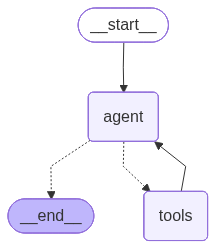

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
from pprint import pprint

inputs = {
    "messages": [
        HumanMessage("스테이크 메뉴의 가격은 얼마인가요?")
    ]
}

result = graph.invoke(inputs)
messages = result.get("messages", [])

for message in messages:
    message.pretty_print()

================================ Human Message =================================

스테이크 메뉴의 가격은 얼마인가요?
================================== Ai Message ==================================
Tool Calls:
  search_menu (call_vXKIu4ezAWxEpvlNS5gNIp6J)
 Call ID: call_vXKIu4ezAWxEpvlNS5gNIp6J
  Args:
    query: 스테이크 가격
================================= Tool Message =================================
Name: search_menu

<Document href="./data/restaurant_menu.txt">
7. 랍스터 비스크
   • 가격: ₩28,000
   • 주요 식재료: 랍스터, 생크림, 브랜디, 파프리카
   • 설명: 랍스터 껍질과 육수로 오랜 시간 우려낸 진한 비스크 수프입니다. 생크림으로 부드러운 질감을 더하고 브랜디로 깊은 풍미를 살렸습니다. 작은 랍스터 살을 토핑으로 올려 고급스러움을 더했습니다.
</Document>
---
<Document href="./data/restaurant_menu.txt">
8. 안심 스테이크 샐러드
   • 가격: ₩26,000
   • 주요 식재료: 소고기 안심, 루꼴라, 체리 토마토, 발사믹 글레이즈
   • 설명: 부드러운 안심 스테이크를 얇게 슬라이스하여 신선한 루꼴라 위에 올린 메인 요리 샐러드입니다. 체리 토마토와 파마산 치즈 플레이크로 풍미를 더하고, 발사믹 글레이즈로 마무리하여 고기의 풍미를 한층 끌어올렸습니다.
</Document>
================================== Ai Message ==================================

안심 스테이크 샐러드(안심

In [16]:
system_prompt = dedent("""
You are an AI assistant designed to answer human questions. 
You can use the provided tools to help generate your responses.

Follow these steps to answer questions:
    1. Carefully read and understand the question.
    2. Use the provided tools to obtain necessary information.
    3. Immediately after using a tool, cite the source using the format below.
    4. Construct an accurate and helpful answer using the tool outputs and citations.
    5. Provide the final answer when you determine it's complete.

When using tools, follow this format:
    Action: tool_name
    Action Input: input for the tool

Immediately after receiving tool output, cite the source as follows:
    [Source: tool_name | document_title/item_name | url/file_path]

For example:
    Action: search_menu
    Action Input: 스테이크
    
    (After receiving tool output)
    [Source: search_menu | 스테이크 | ./data/data.txt]
    스테이크에 대한 정보는 다음과 같습니다...

    Action: search_web
    Action Input: History of AI

    (After receiving tool output)
    [Source: search_web | AI History | https://en.wikipedia.org/wiki/History_of_artificial_intelligence]
    AI의 역사는 다음과 같이 요약됩니다...

If tool use is not necessary, answer directly.

Your final answer should be clear, concise, and directly related to the user's question. 
Ensure that every piece of factual information in your response is accompanied by a citation.

Remember: ALWAYS include these citations for all factual information, tool outputs, and referenced documents in your response. 
Do not provide any information without a corresponding citation.
""")


In [17]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-mini")

tools = [search_menu, search_web]
llm_with_tools = llm.bind_tools(tools=tools)

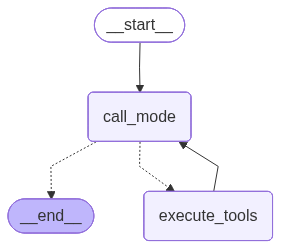

In [18]:
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

class GraphState(MessagesState): # messages 포함
    pass

def call_mode(state: GraphState) -> GraphState:
    system_message = SystemMessage(content=system_prompt)
    messages = [system_message] + state['messages']
    response = llm_with_tools.invoke(messages)
    
    return {"messages": [response]}


def should_continue(state: GraphState):
    last_message = state['messages'][-1]
    print("last_message: ", last_message.tool_calls)
    if last_message.tool_calls:
        return "execute_tools"
    
    return END


builder = StateGraph(GraphState)
builder.add_node("call_mode", call_mode)
builder.add_node("execute_tools", ToolNode(tools))

builder.add_edge(START, "call_mode")
builder.add_conditional_edges(
    "call_mode",
    should_continue,
    {
      "execute_tools" : "execute_tools",
      END : END 
    }
)
builder.add_edge("execute_tools", "call_mode")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
from pprint import pprint

inputs = {
    "messages": [
        HumanMessage("스테이크 메뉴의 가격은 얼마인가요?")
    ]
}

result = graph.invoke(inputs)
messages = result.get("messages", [])

for message in messages:
    message.pretty_print()

last_message:  [{'name': 'search_menu', 'args': {'query': '스테이크'}, 'id': 'call_gIWhEamyrQ0F6wXqlH5ozGSI', 'type': 'tool_call'}]
last_message:  []
================================ Human Message =================================

스테이크 메뉴의 가격은 얼마인가요?
================================== Ai Message ==================================
Tool Calls:
  search_menu (call_gIWhEamyrQ0F6wXqlH5ozGSI)
 Call ID: call_gIWhEamyrQ0F6wXqlH5ozGSI
  Args:
    query: 스테이크
================================= Tool Message =================================
Name: search_menu

<Document href="./data/restaurant_menu.txt">
8. 안심 스테이크 샐러드
   • 가격: ₩26,000
   • 주요 식재료: 소고기 안심, 루꼴라, 체리 토마토, 발사믹 글레이즈
   • 설명: 부드러운 안심 스테이크를 얇게 슬라이스하여 신선한 루꼴라 위에 올린 메인 요리 샐러드입니다. 체리 토마토와 파마산 치즈 플레이크로 풍미를 더하고, 발사믹 글레이즈로 마무리하여 고기의 풍미를 한층 끌어올렸습니다.
</Document>
---
<Document href="./data/restaurant_menu.txt">
7. 랍스터 비스크
   • 가격: ₩28,000
   • 주요 식재료: 랍스터, 생크림, 브랜디, 파프리카
   • 설명: 랍스터 껍질과 육수로 오랜 시간 우려낸 진한 비스크 수프입니다. 생크림으로 부드러운 질감을 더하고 브랜디로 깊은 풍미를 살렸습니